In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from src.config import DADOS_TRATADOS


sns.set_theme(palette="bright")
RANDOM_STATE = 42

In [3]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade             442 non-null    int8   
 1   sexo              442 non-null    int8   
 2   imc               442 non-null    float32
 3   pressao_media     442 non-null    float32
 4   colesterol_total  442 non-null    int16  
 5   ldl               442 non-null    float32
 6   hdl               442 non-null    float32
 7   colesterol_hdl    442 non-null    float32
 8   triglicerides     442 non-null    float32
 9   glicose           442 non-null    int8   
 10  target            442 non-null    int16  
dtypes: float32(6), int16(2), int8(3)
memory usage: 13.5 KB


In [10]:
'''Quando desenvolvemos um modelo de machine learning, nosso objetivo principal é criar um sistema que seja capaz de fazer previsões precisas em dados que o modelo nunca viu antes. Para alcançar esse objetivo, precisamos garantir que o modelo não apenas aprenda os padrões dos dados de treinamento, mas que também seja capaz de generalizar esse aprendizado para novos dados.

#### **Base de Treinamento (Training Set)**

A base de treinamento é a parte dos dados que o modelo utiliza para aprender. Nessa etapa, o modelo ajusta seus parâmetros internos, como os coeficientes de uma regressão linear ou os pesos de uma forma geral, para minimizar o erro em relação aos dados de treinamento.

- **Objetivo**: Permitir que o modelo aprenda as relações e padrões presentes nos dados. Durante o treinamento, o modelo é exposto a esses dados repetidamente para refinar sua capacidade de fazer previsões.

- **Risco**: Se o modelo tiver muita capacidade (por exemplo, se for muito complexo), ele pode "memorizar" os dados de treinamento, resultando em overfitting. Overfitting ocorre quando o modelo se ajusta tão bem aos dados de treinamento que perde a capacidade de generalizar para novos dados.**#

#### **Base de Teste (Test Set)**

### **A base de teste, por outro lado, é um conjunto de dados separado que o modelo não vê durante o treinamento. Esse conjunto é reservado exclusivamente para avaliar o desempenho do modelo após ele ter sido treinado.

- **Objetivo**: Fornecer uma estimativa imparcial do desempenho do modelo em dados novos, simulando como ele se comportaria em um ambiente real. Como o modelo não teve acesso a esses dados durante o treinamento, seu desempenho na base de teste é um bom indicador de sua capacidade de generalização.

- **Risco**: Se a base de teste for usada de forma inadequada, por exemplo, se for utilizada para ajustar hiperparâmetros ou refinar o modelo, ela pode deixar de ser um teste imparcial, levando a uma avaliação excessivamente otimista do desempenho do modelo.

### Importância da Separação

1. **Avaliação da Generalização**:
   - A principal razão para separar os dados em treino e teste é avaliar a capacidade do modelo de generalizar para novos dados. Sem essa separação, não teríamos como medir o quanto o modelo aprendeu de forma robusta ou se ele está simplesmente memorizando os dados de treinamento.

2. **Detecção de Overfitting e Underfitting**:
   - Ao comparar o desempenho do modelo nos dados de treinamento e teste, podemos identificar problemas de overfitting (quando o desempenho no treino é muito melhor do que no teste) e underfitting (quando o desempenho é ruim em ambos).

3. **Validação Imparcial**:
   - Usar um conjunto de dados separado para teste garante que a avaliação do modelo seja imparcial e reflita seu verdadeiro desempenho em situações do mundo real.

### Procedimentos Relacionados

- **Cross-Validation**: Para mitigar o risco de que a divisão específica dos dados em treino e teste possa influenciar os resultados, muitas vezes utilizamos a técnica de validação cruzada (cross-validation). Nessa técnica, o conjunto de dados é dividido em várias partes, e o treinamento e teste são realizados múltiplas vezes, cada vez com uma parte diferente dos dados reservada para teste. Isso fornece uma estimativa mais robusta do desempenho do modelo.'''



'Quando desenvolvemos um modelo de machine learning, nosso objetivo principal é criar um sistema que seja capaz de fazer previsões precisas em dados que o modelo nunca viu antes. Para alcançar esse objetivo, precisamos garantir que o modelo não apenas aprenda os padrões dos dados de treinamento, mas que também seja capaz de generalizar esse aprendizado para novos dados.\n\n#### **Base de Treinamento (Training Set)**\n\nA base de treinamento é a parte dos dados que o modelo utiliza para aprender. Nessa etapa, o modelo ajusta seus parâmetros internos, como os coeficientes de uma regressão linear ou os pesos de uma forma geral, para minimizar o erro em relação aos dados de treinamento.\n\n- **Objetivo**: Permitir que o modelo aprenda as relações e padrões presentes nos dados. Durante o treinamento, o modelo é exposto a esses dados repetidamente para refinar sua capacidade de fazer previsões.\n\n- **Risco**: Se o modelo tiver muita capacidade (por exemplo, se for muito complexo), ele pode 

In [9]:
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [14]:
X = df.drop(columns="target")
y = df["target"]#Coluna alvo

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE#De maneira geral a gente passa muito mais para treino doque para testee nesse caso o padrap que passamos para o test_size é 0.25
)#Vou fazer o unpacking desses resultados que vai me trazer varias tuplas.

In [15]:
X_train.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose
17,68,2,27.500000,111.0,214,147.000000,39.0,5.0,4.9416,91
66,46,2,24.700001,85.0,174,123.199997,30.0,6.0,4.6444,96
137,50,1,31.000000,123.0,178,105.000000,48.0,4.0,4.8283,88
245,41,1,23.100000,86.0,148,78.000000,58.0,3.0,4.0943,60
31,42,1,20.299999,71.0,161,81.199997,66.0,2.0,4.2341,81


In [20]:
X_train.shape

(353, 10)

In [16]:
X_test.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose
287,61,1,25.799999,90.000000,280,195.399994,55.0,5.0,4.9972,90
211,74,1,29.799999,101.000000,171,104.800003,50.0,3.0,4.3944,86
72,66,2,26.000000,91.000000,264,146.600006,65.0,4.0,5.5683,87
321,75,1,31.200001,117.669998,229,138.800003,29.0,7.9,5.7236,106
73,52,2,24.500000,94.000000,217,149.399994,48.0,5.0,4.5850,89


In [18]:
X_test.shape

(89, 10)

In [21]:
y_train.head()

17     144
66     150
137    280
245    125
31      59
Name: target, dtype: int16

In [22]:
y_test.head()

287    219
211     70
72     202
321    230
73     111
Name: target, dtype: int16

In [23]:
regressor = LinearRegression()

regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
regressor.score(X_train, y_train)

0.5279194116592407

In [25]:
regressor.score(X_test, y_test)

0.4526025056838989

In [ ]:
#O valor como você pode analisar esta diferente porque estamos lidando com valores distintos, e a base de treino é melhor do que a base de teste porque a final de contas, o seu modelo viu a base de treino então ele tende se ajustar relativamente bem e se fosse ao contrarrio quer dizer que aquele modelo não era adequeado para aquela situação.

In [26]:
regressor.coef_

array([  0.13768668, -23.064453  ,   5.8463573 ,   1.1970928 ,
        -1.2816892 ,   0.81115264,   0.6016542 ,  10.159543  ,
        67.10896   ,   0.20159943], dtype=float32)

In [ ]:
#Temos varios coeficientes porque é cada coeficiente para cada feture

In [27]:
regressor.intercept_

np.float32(-341.37738)

In [ ]:
#E para melhor vizualização eu vou criar um dataframe

In [32]:
coefs = pd.DataFrame(
    data=regressor.coef_,
    index= X.columns,
    columns=["coeficiente"],
).sort_values(by="coeficiente")

coefs

,coeficiente
sexo,-23.064453
colesterol_total,-1.281689
idade,0.137687
glicose,0.201599
hdl,0.601654
ldl,0.811153
pressao_media,1.197093
imc,5.846357
colesterol_hdl,10.159543
triglicerides,67.108963


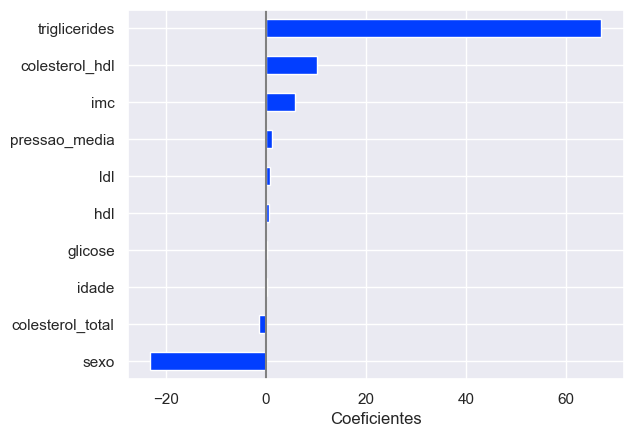

In [36]:
coefs.plot.barh()

plt.axvline(x = 0, color = "0.5");
plt.xlabel("Coeficientes")

plt.gca().get_legend().remove() #esse gca seria para pegar o sistema de eixos

plt.show()